# Convergence curves — char vs every WordPiece vocab_size in the grid

Reads the per-epoch history files `scripts/compare_forward_tokenizers.py` writes under
`<output-root>/history/*.json`, and plots train/val loss vs epoch as one small subplot
per config (char + every vocab_size, and every `--max-token-len` variant present).

Interpretation goes in markdown cells, not on the plots themselves.

In [1]:
# parameters
RESULTS_DIR = "../artifacts/compare_forward_tokenizers_2026-08-01_fine_grid_individual_maxlen_maxtokenlen9_anchored_40epochs"

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_dir = Path(RESULTS_DIR)
raw = pd.read_csv(results_dir / "raw_results.csv")
if "max_token_len" not in raw.columns:
    raw["max_token_len"] = None  # older raw_results.csv, from before --max-token-len existed
if "pad_layout" not in raw.columns:
    raw["pad_layout"] = "end"  # older raw_results.csv, from before --pad-layout existed

print(f"{len(raw)} runs across {raw[['tokenizer','vocab_size','max_token_len']].drop_duplicates().shape[0]} configs")
raw.head()

15 runs across 15 configs


,tokenizer,vocab_size,max_token_len,pad_layout,max_len,seed,test_loss,test_cosine,best_val_loss,epochs_to_best_val,train_time_sec,inference_time_sec,num_parameters,tokenizer_path
0,char,25,NaN,end,40,1,0.197678,0.867836,0.192469,33,1148.349279,0.551894,10850856,NaN
1,wordpiece,1000,9.0,anchored,11,1,0.222379,0.850060,0.219529,25,815.802114,0.472949,10913256,artifacts/tokenizers_2026-08-01_fine_grid/word...
2,wordpiece,2000,9.0,anchored,10,1,0.235747,0.840743,0.229570,27,800.566907,0.497766,10977256,artifacts/tokenizers_2026-08-01_fine_grid/word...
3,wordpiece,2998,9.0,anchored,10,1,0.242457,0.835847,0.240230,38,792.818900,0.469587,11041128,artifacts/tokenizers_2026-08-01_fine_grid/word...
4,wordpiece,3986,9.0,anchored,10,1,0.250418,0.830416,0.247915,38,793.682630,0.471941,11104360,artifacts/tokenizers_2026-08-01_fine_grid/word...


## Load per-epoch history for every run

In [3]:
def history_filename(row):
    """Mirrors compare_forward_tokenizers.py's run_one() naming exactly, so this stays in
    sync with whatever that script actually wrote - no separate parsing of filenames."""
    label = "char" if row["tokenizer"] == "char" else f"wordpiece_{int(row['vocab_size'])}"
    max_token_len = row["max_token_len"]
    filter_suffix = f"_n{int(max_token_len)}" if pd.notna(max_token_len) else ""
    pad_layout = row.get("pad_layout", "end")
    layout_suffix = f"_{pad_layout}" if pad_layout != "end" else ""
    return f"{label}{filter_suffix}{layout_suffix}_seed{int(row['seed'])}.json"


records = []
missing = []
for _, row in raw.iterrows():
    history_path = results_dir / "history" / history_filename(row)
    if not history_path.exists():
        missing.append(history_path.name)
        continue
    with open(history_path) as f:
        history = json.load(f)
    for entry in history:
        for split in ("train", "val"):
            records.append({
                "tokenizer": row["tokenizer"],
                "vocab_size": row["vocab_size"],
                "max_token_len": row["max_token_len"],
                "pad_layout": row.get("pad_layout", "end"),
                "seed": row["seed"],
                "epoch": entry["epoch"],
                "split": split,
                "loss": entry[split]["loss"],
                "cosine": entry[split]["cosine"],
            })

history_df = pd.DataFrame.from_records(records)
if missing:
    print(f"Missing {len(missing)} history file(s), e.g. {missing[:5]} - those runs are skipped below.")
print(f"Loaded {len(history_df)} (config, seed, epoch, split) rows from history/")

Loaded 1200 (config, seed, epoch, split) rows from history/


## Loss vs epoch, one subplot per config

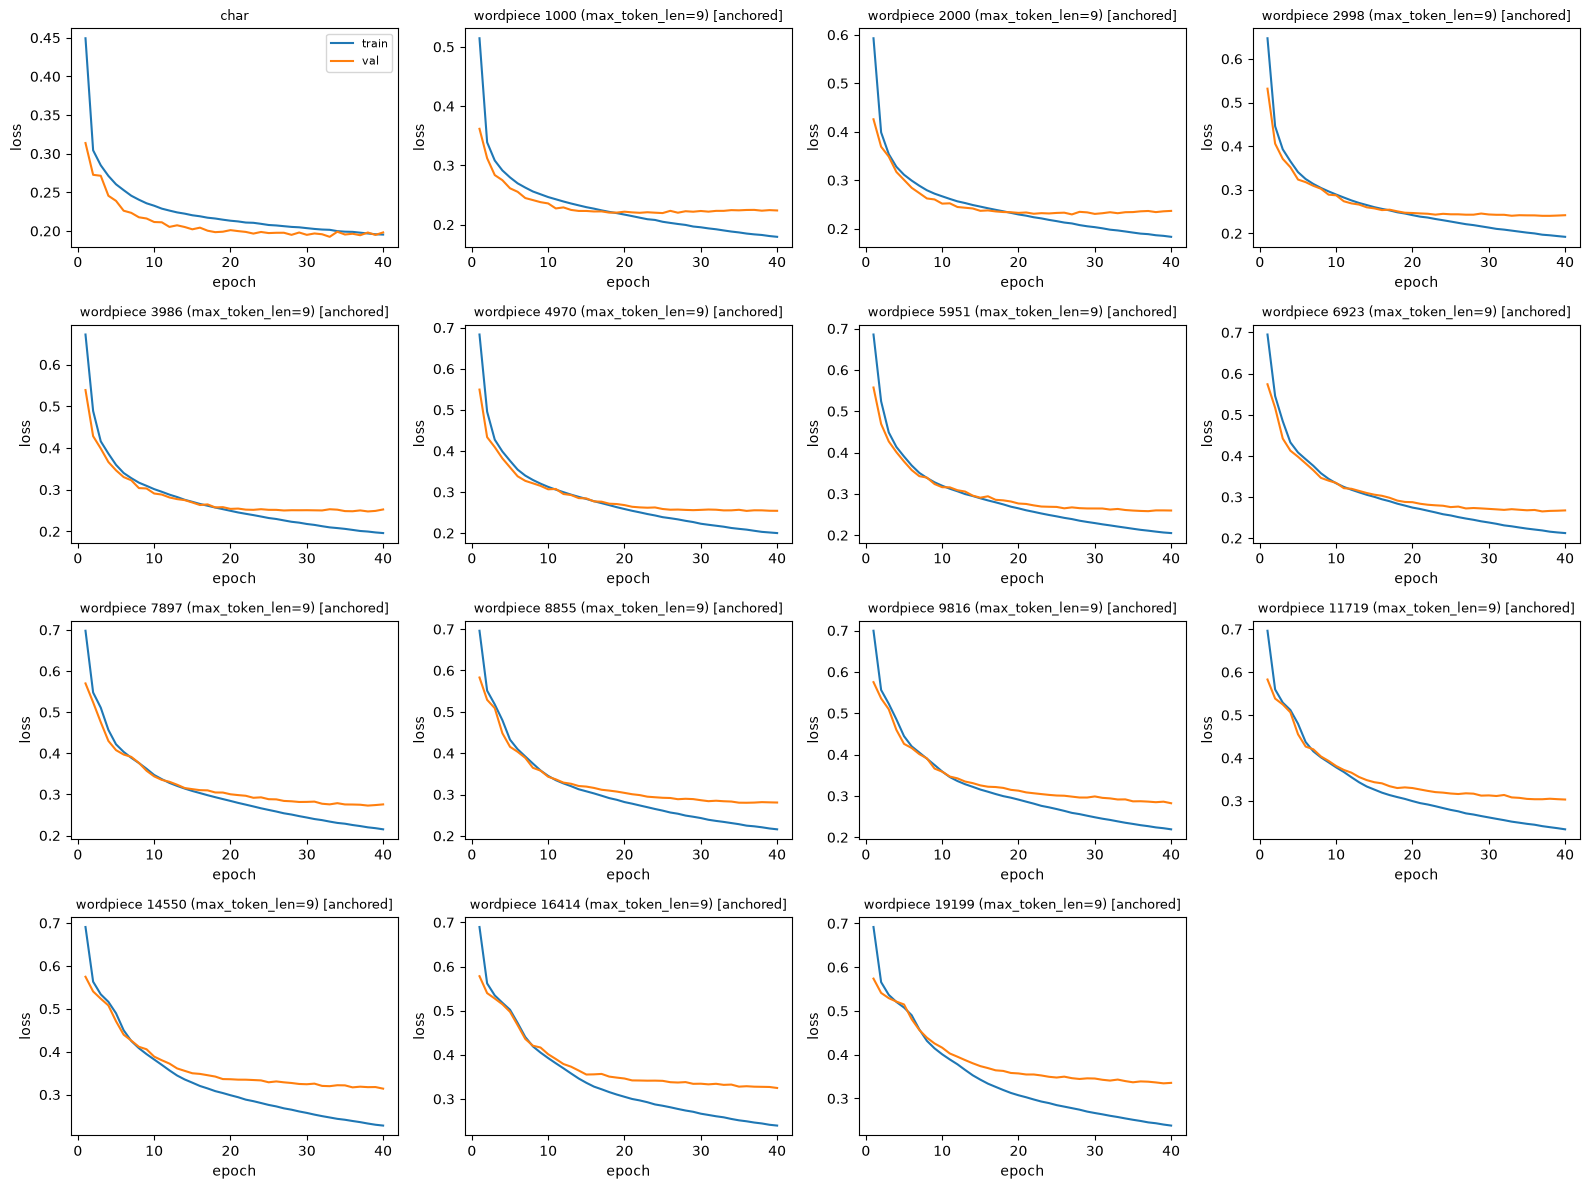

In [4]:
def config_label(tokenizer, vocab_size, max_token_len, pad_layout="end"):
    if tokenizer == "char":
        return "char"
    label = f"wordpiece {int(vocab_size)}"
    if pd.notna(max_token_len):
        label += f" (max_token_len={int(max_token_len)})"
    if pad_layout != "end":
        label += f" [{pad_layout}]"
    return label


configs = (
    history_df[["tokenizer", "vocab_size", "max_token_len", "pad_layout"]]
    .drop_duplicates()
    .sort_values(["tokenizer", "vocab_size", "max_token_len", "pad_layout"], na_position="first")
    .to_records(index=False)
)

n = len(configs)
ncols = min(4, n)
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)

for ax, (tokenizer, vocab_size, max_token_len, pad_layout) in zip(axes.flat, configs):
    subset = history_df[
        (history_df["tokenizer"] == tokenizer)
        & (history_df["vocab_size"] == vocab_size)
        & (history_df["max_token_len"].isna() if pd.isna(max_token_len) else history_df["max_token_len"] == max_token_len)
        & (history_df["pad_layout"] == pad_layout)
    ]
    for split, color in [("train", "tab:blue"), ("val", "tab:orange")]:
        split_data = subset[subset["split"] == split]
        per_epoch = split_data.groupby("epoch")["loss"].agg(["mean", "std"])
        ax.plot(per_epoch.index, per_epoch["mean"], color=color, label=split)
        if per_epoch["std"].notna().any():
            ax.fill_between(per_epoch.index, per_epoch["mean"] - per_epoch["std"].fillna(0),
                             per_epoch["mean"] + per_epoch["std"].fillna(0), color=color, alpha=0.15)
    ax.set_title(config_label(tokenizer, vocab_size, max_token_len, pad_layout), fontsize=9)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")

for ax in axes.flat[n:]:
    ax.axis("off")

axes.flat[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

*Notes: line = mean across seeds, shaded band = std across seeds (band is flat/invisible
with only 1 seed). Train and val loss diverging within a config is the usual overfitting
signal; a val curve still trending down at the last epoch means that config likely hasn't
converged yet.*

## Loss vs epoch, all configs overlaid (val split only)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
val_data = history_df[history_df["split"] == "val"]

for tokenizer, vocab_size, max_token_len, pad_layout in configs:
    subset = val_data[
        (val_data["tokenizer"] == tokenizer)
        & (val_data["vocab_size"] == vocab_size)
        & (val_data["max_token_len"].isna() if pd.isna(max_token_len) else val_data["max_token_len"] == max_token_len)
        & (val_data["pad_layout"] == pad_layout)
    ]
    per_epoch = subset.groupby("epoch")["loss"].mean()
    style = "--" if tokenizer == "char" else "-"
    ax.plot(per_epoch.index, per_epoch.values, style,
            label=config_label(tokenizer, vocab_size, max_token_len, pad_layout), linewidth=1.5 if tokenizer == "char" else 1)

ax.set_xlabel("epoch")
ax.set_ylabel("val_loss")
ax.set_title("val_loss vs epoch, all configs")
ax.legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout()
plt.show()

*Notes: same data as the small-multiples grid above, just overlaid for a direct
side-by-side comparison of convergence speed and final level. `char` is dashed to stand
out from the WordPiece vocab_size curves.*